# 02. Analyze experiments

이 노트북은 학습하지 않습니다. `01_train_experiments.ipynb`에서 저장한 history와 gradient CSV를 읽어 여러 seed의 평균·표준편차 및 그래프를 생성합니다.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (Path('D:/gt-super') / 'data').exists():
    ROOT = Path('D:/gt-super')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from gt_aux.config import ExperimentConfig
from gt_aux.data import prepare_data
from gt_aux.eval import evaluate_saved_experiment, visualize_main_predictions

d:\gt-super\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 분석 대상

완료된 seed만 `SEEDS`에 적습니다. 예: `SEEDS = [42, 43, 44]`.

In [2]:
RUN_MODE = 'smoke'
SEEDS = [42, 43,44]
DATA_SEED = 42
EXPERIMENTS = ['baseline', 'shared_detach', 'shared_e2e', 'separate_e2e']

# checkpoint 재평가는 최종 CSV와 checkpoint가 일치하는지 확인할 때만 사용합니다.
RUN_CHECKPOINT_EVALUATION = False
SAVE_DETAILED_GRADIENT_CSV = False
PREDICTION_EXPERIMENT = 'shared_e2e'
PREDICTION_SEED = SEEDS[0]

CONFIG = ExperimentConfig(
    ROOT, run_mode=RUN_MODE, seed=SEEDS[0], data_seed=DATA_SEED, experiments=EXPERIMENTS
)

In [3]:
history_frames, gradient_frames, missing_files = [], [], []
for seed in SEEDS:
    for experiment in EXPERIMENTS:
        history_path = CONFIG.history_path(experiment, seed)
        gradient_path = CONFIG.gradients_path(experiment, seed)
        if history_path.exists():
            history_frames.append(pd.read_csv(history_path))
        else:
            missing_files.append(str(history_path))
        if gradient_path.exists() and gradient_path.stat().st_size > 0:
            try:
                gradient_frame = pd.read_csv(gradient_path)
            except pd.errors.EmptyDataError:
                gradient_frame = pd.DataFrame()
            if not gradient_frame.empty:
                gradient_frames.append(gradient_frame)

if missing_files:
    print('Missing history files:')
    print('\n'.join(missing_files))
if not history_frames:
    raise FileNotFoundError('분석할 history CSV가 없습니다.')

history_df = pd.concat(history_frames, ignore_index=True)
gradients_df = pd.concat(gradient_frames, ignore_index=True) if gradient_frames else pd.DataFrame()
if 'data_seed' not in history_df.columns:
    raise ValueError('Old history without data_seed detected; rerun training with fixed data split code.')
observed_data_seeds = sorted(history_df['data_seed'].dropna().unique().tolist())
if observed_data_seeds != [DATA_SEED]:
    raise ValueError(f'Data split mismatch: expected {DATA_SEED}, found {observed_data_seeds}')
print({'history_runs': history_df[['experiment', 'seed']].drop_duplicates().shape[0],
       'gradient_runs': gradients_df[['experiment', 'seed']].drop_duplicates().shape[0] if not gradients_df.empty else 0})

{'history_runs': 12, 'gradient_runs': 6}


## 최종 성능 평균 ± 표준편차

In [4]:
final_rows = history_df.sort_values('epoch').groupby(['experiment', 'seed'], as_index=False).tail(1)
metric_columns = ['map', 'map50', 'map75', 'mar100', 'main_loss']
summary_df = final_rows.groupby('experiment')[metric_columns].agg(['mean', 'std', 'count'])
display(summary_df)
summary_path = CONFIG.output_dir / f'multi_seed_summary_{RUN_MODE}.csv'
summary_df.to_csv(summary_path)
print('Saved:', summary_path)

map                     map50                     map75  \
                   mean       std count      mean       std count      mean   
experiment                                                                    
baseline       0.068845  0.030949     3  0.117897  0.040832     3  0.071832   
separate_e2e   0.078479  0.007391     3  0.127680  0.011895     3  0.087140   
shared_detach  0.076090  0.005782     3  0.127558  0.010153     3  0.079733   
shared_e2e     0.080148  0.023734     3  0.129905  0.035554     3  0.081530   

                                 mar100                 main_loss            \
                    std count      mean       std count      mean       std   
experiment                                                                    
baseline       0.033281     3  0.387978  0.051572     3  1.512701  0.054023   
separate_e2e   0.007738     3  0.431719  0.007152     3  1.379707  0.034633   
shared_detach  0.010863     3  0.399006  0.013754     3  1.468223  0.043085   
shared_e2e     0.021667     3  0.403591  0.008868     3  1.352981  0.029972   

                     
              count  
experiment           
baseline          3  
separate_e2e      3  
shared_detach     3  
shared_e2e        3

Saved: D:\gt-super\outputs\detr_gt_auxiliary\multi_seed_summary_smoke.csv


Saved: D:\gt-super\outputs\detr_gt_auxiliary\multi_seed_performance_smoke.png


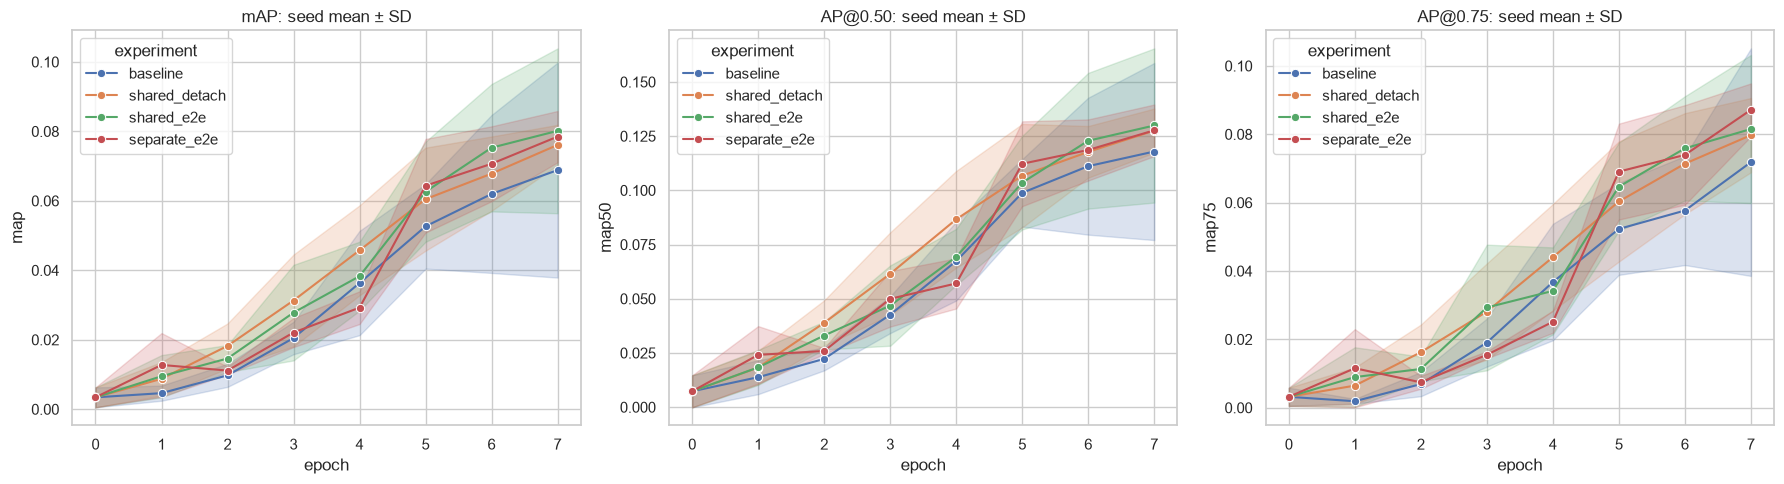

In [5]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, metric, title in zip(
    axes, ['map', 'map50', 'map75'], ['mAP', 'AP@0.50', 'AP@0.75']
):
    sns.lineplot(
        data=history_df, x='epoch', y=metric, hue='experiment',
        estimator='mean', errorbar='sd' if len(SEEDS) > 1 else None,
        marker='o', ax=axis,
    )
    axis.set_title(f'{title}: seed mean' + (' ± SD' if len(SEEDS) > 1 else ''))
plt.tight_layout()
performance_plot_path = CONFIG.output_dir / f'multi_seed_performance_{RUN_MODE}.png'
fig.savefig(performance_plot_path, dpi=180, bbox_inches='tight')
print('Saved:', performance_plot_path)
plt.show()

## Gradient 진단

Saved: D:\gt-super\outputs\detr_gt_auxiliary\multi_seed_gradients_smoke.png


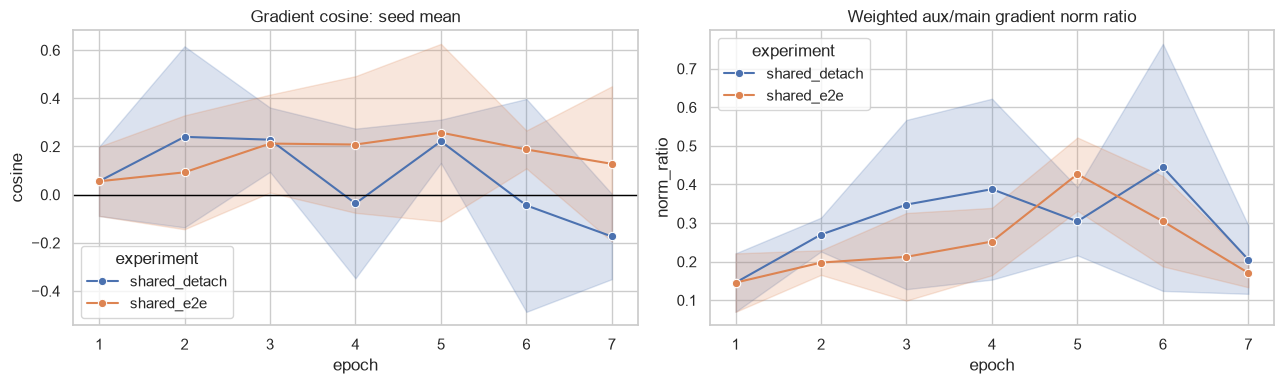

In [6]:
if gradients_df.empty:
    print('저장된 gradient 결과가 없습니다.')
else:
    gradient_summary_df = gradients_df.groupby(['experiment', 'epoch'])[[
        'cosine', 'main_grad_norm', 'weighted_aux_grad_norm', 'norm_ratio'
    ]].agg(['mean', 'std', 'count'])
    if SAVE_DETAILED_GRADIENT_CSV:
        gradient_summary_df.to_csv(CONFIG.output_dir / f'multi_seed_gradients_{RUN_MODE}.csv')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.lineplot(data=gradients_df, x='epoch', y='cosine', hue='experiment',
                 estimator='mean', errorbar='sd' if len(SEEDS) > 1 else None, marker='o', ax=axes[0])
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_title('Gradient cosine: seed mean')
    sns.lineplot(data=gradients_df, x='epoch', y='norm_ratio', hue='experiment',
                 estimator='mean', errorbar='sd' if len(SEEDS) > 1 else None, marker='o', ax=axes[1])
    axes[1].set_title('Weighted aux/main gradient norm ratio')
    plt.tight_layout()
    gradient_plot_path = CONFIG.output_dir / f'multi_seed_gradients_{RUN_MODE}.png'
    fig.savefig(gradient_plot_path, dpi=180, bbox_inches='tight')
    print('Saved:', gradient_plot_path)
    plt.show()

## 선택적 checkpoint 재평가 및 예측 시각화

In [7]:
if RUN_CHECKPOINT_EVALUATION:
    BUNDLE = prepare_data(CONFIG)
    evaluation_rows = [
        evaluate_saved_experiment(CONFIG, BUNDLE, experiment, seed)
        for seed in SEEDS for experiment in EXPERIMENTS
    ]
    evaluation_df = pd.DataFrame(evaluation_rows)
    display(evaluation_df)
    evaluation_df.to_csv(CONFIG.output_dir / f'multi_seed_checkpoint_eval_{RUN_MODE}.csv', index=False)
    visualize_main_predictions(
        CONFIG, BUNDLE, experiment=PREDICTION_EXPERIMENT,
        seed=PREDICTION_SEED, count=4, threshold=0.2,
    )
else:
    print('Checkpoint 재평가 생략: RUN_CHECKPOINT_EVALUATION=False')

Checkpoint 재평가 생략: RUN_CHECKPOINT_EVALUATION=False
